# 08 — Full Bracket Simulation = Championship Probability before the Playoffs

**Question:** before the first playoff game - which team has the best title probability?

**Approach:**
1. Per season, find each teams **pre-playoff ELO** (= ELO right before playoff game 1)
2. From the actual bracket structure I identify **which series feeds into which** (R1 → R2 → R3 → Finals)
3. Monte Carlo simulation: play out the entire bracket 10,000 times, with ELO-based per-game probability + best-of-7 format
4. Every team gets a **championship probability**
5. Backtest: was the actual champion in my top-3 / top-5?

I stick with **ELO only** for the bracket simulation. ELO is the clean, transparent team-strength metric.

## 1. Setup

In [11]:
#packages
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# plot style Latex <3
sys.path.insert(0, str(Path("..").resolve()))
from src.plot_style import apply
apply()

RNG = np.random.default_rng(42)

DATA = Path("..") / "data" / "processed"
df = pd.read_parquet(DATA / "games_with_advanced_features.parquet")
print(f"Games: {len(df):,}")

Games: 71,239


## 2. Pre-playoff ELO per (season, team)


In [13]:
playoffs = df[df.gameType == "Playoffs"].copy()

home_view = playoffs[["season", "gameDate", "hometeamId", "home_elo_pre", "hometeamName"]].rename(
    columns={"hometeamId": "teamId", "home_elo_pre": "elo", "hometeamName": "teamName"})

away_view = playoffs[["season", "gameDate", "awayteamId", "away_elo_pre", "awayteamName"]].rename(
    columns={"awayteamId": "teamId", "away_elo_pre": "elo", "awayteamName": "teamName"})

team_view = pd.concat([home_view, away_view], ignore_index=True).sort_values(["season", "teamId", "gameDate"])

preplayoff_elo = team_view.groupby(["season", "teamId"], as_index=False).first()

print(f"Team-seasons: {len(preplayoff_elo):,}")

preplayoff_elo[preplayoff_elo.season == 2023].sort_values("elo", ascending=False).head(8)

Team-seasons: 964


,season,teamId,gameDate,elo,teamName
916,2023,1610612738,2024-04-21 13:00:00,1719.858221,Celtics
920,2023,1610612743,2024-04-20 20:30:00,1668.029400,Nuggets
931,2023,1610612760,2024-04-21 21:30:00,1642.686109,Thunder
930,2023,1610612756,2024-04-20 15:30:00,1615.945551,Suns
925,2023,1610612750,2024-04-20 15:30:00,1614.794373,Timberwolves
919,2023,1610612742,2024-04-21 15:30:00,1601.528352,Mavericks
926,2023,1610612752,2024-04-20 18:00:00,1599.676671,Knicks
922,2023,1610612747,2024-04-20 20:30:00,1581.873678,Lakers


## 3. ELO based series simulation

Classic formula: $P(A \text{ beats } B) = \frac{1}{1 + 10^{(B_{elo} - A_{elo} - H)/400}}$ with home advantage $H \approx 100$ (see NB_02)

Best of 7 NBA format 2-2-1-1-1

In [14]:
HOME_ADV = 100

def elo_p(team_elo, opp_elo, is_home):
    delta = opp_elo - team_elo - (HOME_ADV if is_home else -HOME_ADV)
    return 1.0 / (1.0 + 10 ** (delta / 400))

def simulate_b07(higher_elo, lower_elo, rng):
    
    """Best of 7. Returns True if higher seed wins."""
    
    home_pattern = [True, True, False, False, True, False, True]
    wins_high = wins_low = 0
    
    for is_high_home in home_pattern:
        p = elo_p(higher_elo, lower_elo, is_high_home)
        
        if rng.random() < p: wins_high += 1
        else: wins_low += 1
        if wins_high == 4: return True
        if wins_low == 4: return False
    
    return wins_high > wins_low

# sanity: +200 ELO advantage at home should give ~80% series win rate

wins = sum(simulate_b07(1700, 1500, RNG) for _ in range(5000))
print(f"+200 ELO advantage (with home court) -> {wins/5000:.1%} series win rate")

+200 ELO advantage (with home court) -> 94.4% series win rate


## 4. Build the bracket tree per season

From the actual games I derive which R1 series fed into which R2 series (parent-child relationship). That gives the slot structure of the bracket - in the simulation other teams may win, but the slots stay the same.

Requirement: 16-team format = exactly 15 series per season (8+4+2+1)

In [16]:
playoffs["team_pair"] = playoffs.apply(lambda r: tuple(sorted([r.hometeamId, r.awayteamId])), axis=1)

def build_bracket_for_season(season):
    s_games = playoffs[playoffs.season == season]
    series_list = []
    
    for pair, grp in s_games.groupby("team_pair"):
        
        if len(grp) < 3:            
            return None  # incomplete
            
        higher = grp.hometeamId.value_counts().idxmax()
        lower = [t for t in pair if t != higher][0]
        wins_h = ((grp.hometeamId == higher) & (grp.home_win == 1)).sum() + \
                 ((grp.awayteamId == higher) & (grp.home_win == 0)).sum()
        
        higher_won = wins_h > (len(grp) - wins_h)
        winner = higher if higher_won else lower
        
        series_list.append({
            "higher": higher, "lower": lower, "winner": winner,
            "first_date": grp.gameDate.min(),})
        
    s = pd.DataFrame(series_list).sort_values("first_date").reset_index(drop=True)
    
    if len(s) != 15:
        return None
    
    s["round"] = [1]*8 + [2]*4 + [3]*2 + [4]
    s["uid"] = range(len(s))

    # which lower round series sent their winners into this one
    s["parents"] = [[] for _ in range(len(s))]
    
    for r in [2, 3, 4]:
        
        higher_round = s[s["round"] == r]
        lower_round = s[s["round"] == r - 1]
        
        for idx, row in higher_round.iterrows():
            
            teams_here = {row.higher, row.lower}
            parents = [low.uid for _, low in lower_round.iterrows() if low.winner in teams_here]
            
            if len(parents) != 2:
                return None  # bracket cant be cleanly reconstructed
            
            s.at[idx, "parents"] = parents
    
    return s

valid_seasons = []

for season in sorted(playoffs.season.unique()):
    if build_bracket_for_season(season) is not None:
        valid_seasons.append(season)


print(f"Seasons with clean 16-team bracket: {len(valid_seasons)}  ({min(valid_seasons)} - {max(valid_seasons)})")

Seasons with clean 16-team bracket: 40  (1983 - 2024)


## 5. Monte Carlo bracket simulation

Per season: 10,000 simulations. Each sim plays out all 15 series through the bracket tree and counts the champion at the end

In [17]:
def simulate_one_bracket(bracket, team_elos, rng):
    
    winners = {}
    
    for _, srs in bracket.iterrows():
        
        if srs["round"] == 1:
            a, b = srs.higher, srs.lower
        else:
            a = winners[srs.parents[0]]
            b = winners[srs.parents[1]]
        
        elo_a, elo_b = team_elos.get(a, 1500), team_elos.get(b, 1500)
        higher, lower = (a, b) if elo_a >= elo_b else (b, a)
        higher_wins = simulate_b07(team_elos.get(higher, 1500), team_elos.get(lower, 1500), rng)
        winners[srs.uid] = higher if higher_wins else lower
    
    finals_uid = bracket[bracket["round"] == 4].iloc[0].uid
    return winners[finals_uid]

def championship_probs(season, n_sim=10000):
    
    bracket = build_bracket_for_season(season)
    
    if bracket is None:
        return None
    
    teams_in_bracket = sorted(set(bracket.higher) | set(bracket.lower))
    elos = {t: preplayoff_elo[(preplayoff_elo.season == season) & (preplayoff_elo.teamId == t)]["elo"].iloc[0]
            for t in teams_in_bracket}
    
    rng = np.random.default_rng(season)   # deterministic per season
    counts = {t: 0 for t in teams_in_bracket}
    
    for _ in range(n_sim):
        champ = simulate_one_bracket(bracket, elos, rng)
        counts[champ] += 1
    
    return {t: c / n_sim for t, c in counts.items()}, bracket

# test for 2023
probs23, bracket23 = championship_probs(2023, n_sim=10000)
test = pd.Series(probs23, name="p_champion").sort_values(ascending=False)

team_names = pd.concat([
    df[["hometeamId", "hometeamName"]].rename(columns={"hometeamId": "teamId", "hometeamName": "teamName"}),
    df[["awayteamId", "awayteamName"]].rename(columns={"awayteamId": "teamId", "awayteamName": "teamName"}),
]).drop_duplicates("teamId").set_index("teamId")["teamName"]



print("Top-5 championship picks for season 2023:")
print(test.head(5).rename(team_names).round(3))

Top-5 championship picks for season 2023:
Celtics        0.574
Nuggets        0.153
SuperSonics    0.095
Knicks         0.039
Suns           0.031
Name: p_champion, dtype: float64


## 6. Backtest across all seasons

In [18]:
results = []

for season in valid_seasons:
    
    out = championship_probs(season, n_sim=5000)
    
    if out is None: continue
    
    probs, bracket = out
    finals = bracket[bracket['round'] == 4].iloc[0]
    actual_champ = finals.winner
    sorted_picks = sorted(probs.items(), key=lambda kv: kv[1], reverse=True)
    pick_rank = next(i for i, (t, _) in enumerate(sorted_picks) if t == actual_champ) + 1
    
    results.append({
        'season': season,
        'actual_champ': team_names.get(actual_champ, str(actual_champ)),
        'top_pick': team_names.get(sorted_picks[0][0], str(sorted_picks[0][0])),
        'top_pick_p': sorted_picks[0][1],
        'actual_champ_p': probs[actual_champ],
        'actual_champ_rank': pick_rank,})

bt = pd.DataFrame(results)
bt.tail(10).round(3)

,season,actual_champ,top_pick,top_pick_p,actual_champ_p,actual_champ_rank
30,2013,Spurs,Spurs,0.485,0.485,1
31,2014,Warriors,Warriors,0.571,0.571,1
32,2015,Cavaliers,Warriors,0.735,0.025,3
33,2016,Warriors,Warriors,0.717,0.717,1
34,2017,Warriors,Rockets,0.559,0.129,3
35,2018,Raptors,Rockets,0.213,0.134,4
36,2021,Warriors,Suns,0.499,0.015,9
37,2022,Nuggets,Bucks,0.324,0.049,5
38,2023,Celtics,Celtics,0.577,0.577,1
39,2024,SuperSonics,SuperSonics,0.580,0.580,1


In [19]:
summary = pd.Series({
    "Seasons tested":               len(bt),
    "Top-1 hits":                   (bt.actual_champ_rank == 1).sum(),
    "Top-3 hits":                   (bt.actual_champ_rank <= 3).sum(),
    "Top-5 hits":                   (bt.actual_champ_rank <= 5).sum(),
    "Mean prob for real champion":  bt.actual_champ_p.mean(),
    "Median rank position":         bt.actual_champ_rank.median(),
}).round(3)
summary

Seasons tested                 40.00
Top-1 hits                     21.00
Top-3 hits                     30.00
Top-5 hits                     37.00
Mean prob for real champion     0.34
Median rank position            1.00
dtype: float64

## 7. Where did the real champion land in our picks?

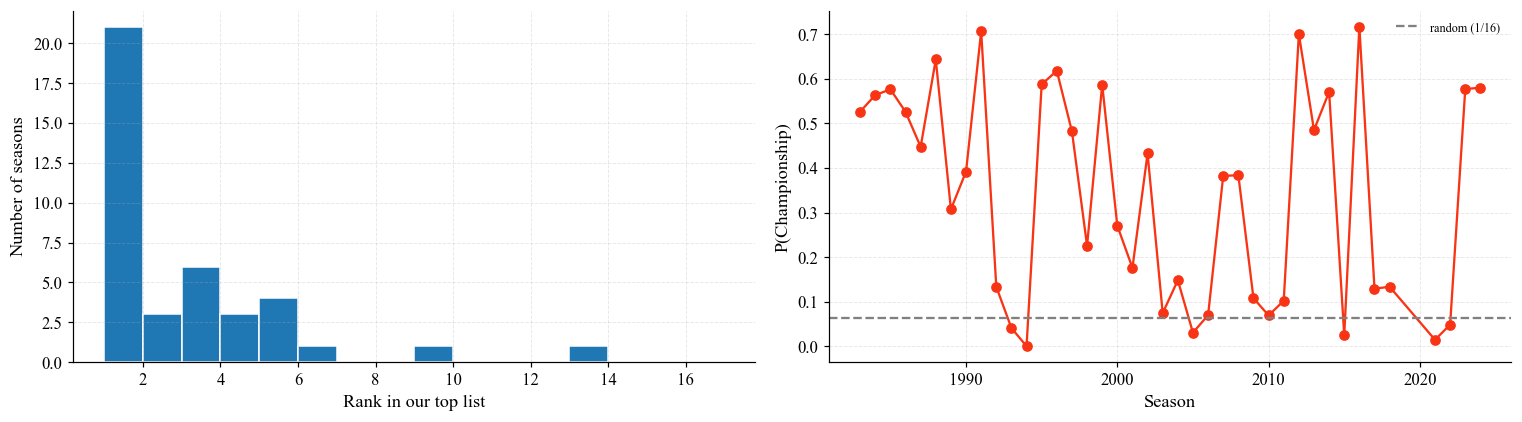

Average: model gave the real champion 34.0% title chance before the playoffs.
Random baseline would be: 6.2%.


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# distribution of the real champion's rank
axes[0].hist(bt.actual_champ_rank, bins=range(1, 18), color="#1f77b4", edgecolor="white")
axes[0].set_xlabel("Rank in our top list")
axes[0].set_ylabel("Number of seasons")

# confidence per year
axes[1].plot(bt.season, bt.actual_champ_p, marker="o", color="#f93414")
axes[1].axhline(1/16, color="gray", linestyle="--", label="random (1/16)")
axes[1].set_xlabel("Season")
axes[1].set_ylabel("P(Championship)")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Average: model gave the real champion {bt.actual_champ_p.mean():.1%} title chance before the playoffs.")
print(f"Random baseline would be: {1/16:.1%}.")

## 8. Example 2023 


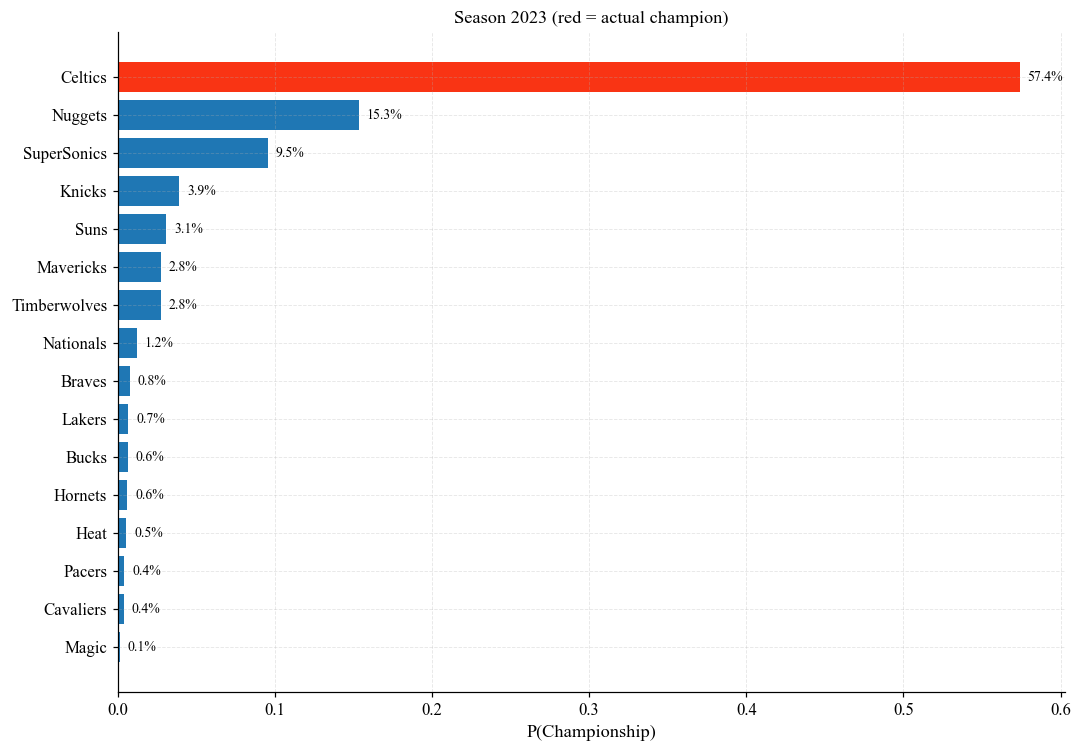

In [21]:
year = 2023

probs, bracket = championship_probs(year, n_sim=10000)
actual = bracket[bracket["round"] == 4].iloc[0].winner

view = pd.Series(probs).rename(team_names).sort_values(ascending=True)
actual_name = team_names[actual]
colors = ["#f93414" if name == actual_name else "#1f77b4" for name in view.index]

fig, ax = plt.subplots(figsize=(10, 7))

ax.barh(view.index, view.values, color=colors)
ax.set_title(f"Season {year} (red = actual champion)")
ax.set_xlabel("P(Championship)")
for i, v in enumerate(view.values):
    ax.text(v + 0.005, i, f"{v:.1%}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

## 9. Save

In [24]:
bt.to_csv(DATA / "bracket_backtest.csv", index=False)
print("Saved: bracket_backtest.csv")

Saved: bracket_backtest.csv
